# Data Preprocessing and Modeling

In [3]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
# load the cleaned dataset from Notebook 1
df = pd.read_csv("../data/model_df.csv")

In [6]:
# target we want to predict
y = df["Overall_Livability_Score"]

# features used to predict target
X = df.drop(columns=["Overall_Livability_Score"])

In [7]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [8]:
# simple baseline model
model = LinearRegression()

# train model on training data
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
# predict livability scores on test data
y_pred = model.predict(X_test)

In [10]:
# check prediction error
print("MAE:", mean_absolute_error(y_test, y_pred))

# check how well model fits data (0 to 1)
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3.363771909620338
R2 Score: 0.7121091800860166


<Axes: >

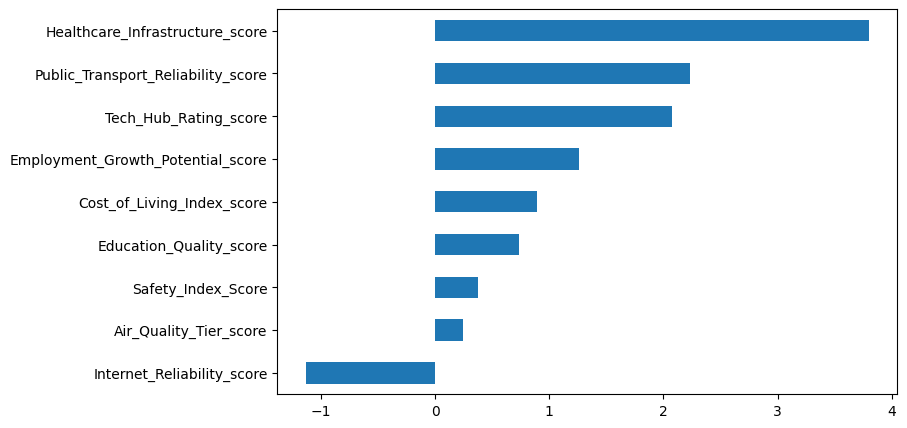

In [11]:
# see which features influence livability most
importance = pd.Series(model.coef_, index=X.columns)

# sort for better readability
importance.sort_values().plot(kind="barh", figsize=(8,5))